In [78]:




import requests

url = "https://eonet.gsfc.nasa.gov/api/v3/events"
response = requests.get(url)
data = response.json()



events = data["events"]



import pandas as pd

rows = []

for event in events:
    for g in event["geometry"]:
        rows.append({
            "event": event["title"],
            "date": g["date"],
            "magnitude": g.get("magnitudeValue"),
            "lat": g["coordinates"][1],
            "lon": g["coordinates"][0]
        })

df = pd.DataFrame(rows)
#save in a folder
df.to_csv("Nasa_Event_data.csv", index=False)
print(df.head(30))



                                                event                  date  \
0                               Super Typhoon Sinlaku  2026-04-09T18:00:00Z   
1                               Super Typhoon Sinlaku  2026-04-10T00:00:00Z   
2                               Super Typhoon Sinlaku  2026-04-10T06:00:00Z   
3                               Super Typhoon Sinlaku  2026-04-10T12:00:00Z   
4                               Super Typhoon Sinlaku  2026-04-10T18:00:00Z   
5                               Super Typhoon Sinlaku  2026-04-11T00:00:00Z   
6                               Super Typhoon Sinlaku  2026-04-11T06:00:00Z   
7                               Super Typhoon Sinlaku  2026-04-11T12:00:00Z   
8                               Super Typhoon Sinlaku  2026-04-11T18:00:00Z   
9                               Super Typhoon Sinlaku  2026-04-12T00:00:00Z   
10                              Super Typhoon Sinlaku  2026-04-12T06:00:00Z   
11  rx-Northern Scupp EWO Prescribed Fire, Waukesh..

In [79]:
df.shape

(7243, 5)

In [80]:
df.columns

Index(['event', 'date', 'magnitude', 'lat', 'lon'], dtype='object')

In [67]:
df["event"].value_counts()

,count
event,
Iceberg A23A,72
Iceberg B15AB,61
Iceberg A74A,54
Iceberg A76C,49
Iceberg D32,48
...,...
Wildfire in Australia 1023374,1
Wildfire in Australia 1023358,1
"APQ NC Range Rx 0115 Wildfire, Polk, Florida",1


In [56]:
print(df.isnull().sum())

event           0
date            0
magnitude    3922
lat             0
lon             0
dtype: int64


,event,date,magnitude,lat,lon,event_type
7238,Iceberg B09B,2011-08-30 00:00:00+00:00,NaN,-66.3660,143.3638,Iceberg
7239,Iceberg B09B,2013-04-08 00:00:00+00:00,NaN,-66.7354,142.6649,Iceberg
7240,Iceberg B09B,2018-01-12 00:00:00+00:00,NaN,-66.3700,143.3900,Iceberg
7241,Iceberg C21B,2011-08-30 00:00:00+00:00,NaN,-64.9955,96.1800,Iceberg
7242,"Fuego Volcano, Guatemala",2002-01-04 00:00:00+00:00,NaN,14.4730,-90.8800,Fuego


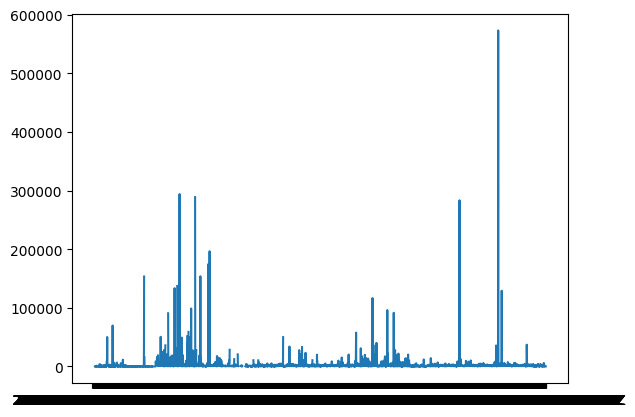

In [58]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values('date')

plt.plot(df_sorted['date'], df_sorted['magnitude'])
plt.show()

In [81]:
wildfire_df = df[df['event'].str.contains(r'\bWildfire\b', case=False, na=False)]

print(wildfire_df)

wildfire_df.to_csv("wildfire_df.csv", index=False)

                                                  event                  date  \
12                   HARRISON Wildfire, Osage, Oklahoma  2026-04-09T13:08:00Z   
13                        JOY Wildfire, Osage, Oklahoma  2026-04-09T11:29:00Z   
15      Rosindale Road Wildfire, Bladen, North Carolina  2026-04-09T10:20:00Z   
17                     HUGHEY Wildfire, Osage, Oklahoma  2026-04-09T09:15:00Z   
21                HC 1 Wildfire, San Miguel, New Mexico  2026-04-08T19:31:00Z   
...                                                 ...                   ...   
6799               Pilot Wildfire, Humboldt, California  2023-08-15T18:41:00Z   
6800            Diamond Wildfire, Del Norte, California  2023-08-15T12:55:00Z   
6801     Black Feather Wildfire, Rio Arriba, New Mexico  2023-08-05T17:59:00Z   
6803  Cocke County Mill Creek Road Fire Wildfire, Co...  2023-03-15T10:00:00Z   
6880                   Fish Wildfire, Greenlee, Arizona  2022-06-10T18:12:00Z   

      magnitude        lat 

In [72]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

# Load your saved wildfire data
Wildfire_df = pd.read_csv("wildfire_df.csv")

# Create map (global view)
m = folium.Map(location=[20, 0], zoom_start=2)

# Add title
title_html = """
<h3 align="center" style="font-size:20px"><b>Wildfire Events Map</b></h3>
"""
m.get_root().html.add_child(folium.Element(title_html))

# Use clustering
cluster = MarkerCluster().add_to(m)
for _, row in Wildfire_df.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"{row['event']} | Mag: {row['magnitude']}"
    ).add_to(cluster)

# Save map
m.save("wildfire_map.html")

m

In [82]:
Typhoon_df = df[df['event'].str.contains(r'\bTyphoon|Severe Typhoon\b', case=False, na=False)]
print(Typhoon_df)
Typhoon_df.to_csv("Typhoon_df.csv", index=False)

                    event                  date  magnitude   lat    lon
0   Super Typhoon Sinlaku  2026-04-09T18:00:00Z       35.0   8.3  151.5
1   Super Typhoon Sinlaku  2026-04-10T00:00:00Z       40.0   8.2  151.2
2   Super Typhoon Sinlaku  2026-04-10T06:00:00Z       45.0   8.2  151.0
3   Super Typhoon Sinlaku  2026-04-10T12:00:00Z       55.0   8.1  150.9
4   Super Typhoon Sinlaku  2026-04-10T18:00:00Z       60.0   8.0  151.0
5   Super Typhoon Sinlaku  2026-04-11T00:00:00Z       75.0   8.5  151.5
6   Super Typhoon Sinlaku  2026-04-11T06:00:00Z       80.0   8.8  151.4
7   Super Typhoon Sinlaku  2026-04-11T12:00:00Z       85.0   9.0  151.1
8   Super Typhoon Sinlaku  2026-04-11T18:00:00Z       95.0   9.3  151.5
9   Super Typhoon Sinlaku  2026-04-12T00:00:00Z      110.0   9.9  151.2
10  Super Typhoon Sinlaku  2026-04-12T06:00:00Z      130.0  10.3  150.6


In [100]:
Typhoon_df.shape

(11, 5)

# Typhoon

In [75]:
import pandas as pd
import folium

# Load Typhoon data
Typhoon_df = pd.read_csv("Typhoon_df.csv")

# Convert date (important for sorting)
Typhoon_df['date'] = pd.to_datetime(Typhoon_df['date'], errors='coerce')

# Sort for path plotting
Typhoon_df = Typhoon_df.sort_values('date')

# Create map (Pacific region focus)
m = folium.Map(location=[10, 130], zoom_start=4)

# Add title
title_html = """
<h3 align="center" style="font-size:20px"><b>Typhoon Events Map</b></h3>
"""
m.get_root().html.add_child(folium.Element(title_html))

# Plot points
for _, row in Typhoon_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(4, row['magnitude']/20),
        color='blue',
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['event']} | Wind: {row['magnitude']} | {row['date']}"
    ).add_to(m)

# Draw path (trajectory)
points = Typhoon_df[['lat', 'lon']].values.tolist()
folium.PolyLine(points, color="blue", weight=3).add_to(m)

# Save map
m.save("typhoon_map.html")

m

In [76]:
Cyclone_df = df[df['event'].str.contains(r'\bCyclone\b', case=False, na=False)]

print(Cyclone_df.head(7))

Cyclone_df.to_csv("Cyclone_df.csv", index=False)

                      event                  date  magnitude   lat    lon
64  Tropical Cyclone Vaianu  2026-04-05T00:00:00Z       40.0 -13.8  171.8
65  Tropical Cyclone Vaianu  2026-04-05T06:00:00Z       55.0 -14.5  172.3
66  Tropical Cyclone Vaianu  2026-04-05T12:00:00Z       60.0 -14.9  172.4
67  Tropical Cyclone Vaianu  2026-04-05T18:00:00Z       75.0 -15.1  172.6
68  Tropical Cyclone Vaianu  2026-04-06T00:00:00Z       80.0 -15.7  173.1
69  Tropical Cyclone Vaianu  2026-04-06T06:00:00Z       90.0 -16.1  173.6
70  Tropical Cyclone Vaianu  2026-04-06T12:00:00Z       95.0 -16.5  173.8


In [83]:
Cyclone_df.shape

(47, 5)

In [88]:

iceberg_df = df[df['event'].str.contains(r'\bIceberg\b', case=False, na=False)]

print(iceberg_df)

iceberg_df.to_csv("Iceberg_events.csv", index=False)

             event                  date  magnitude      lat       lon
644   Iceberg D15C  2026-02-13T00:00:00Z      56.17 -66.8400   81.0500
919   Iceberg C18C  2025-10-31T00:00:00Z      25.93 -66.8900   65.5800
920   Iceberg C18C  2025-11-14T00:00:00Z      20.00 -66.7300   63.9000
921   Iceberg C18C  2025-11-21T00:00:00Z      20.00 -66.6300   62.4400
922   Iceberg C18C  2025-11-28T00:00:00Z      20.00 -66.7500   60.5100
...            ...                   ...        ...      ...       ...
7237   Iceberg C15  2017-12-01T00:00:00Z        NaN -66.2500  143.3600
7238  Iceberg B09B  2011-08-30T00:00:00Z        NaN -66.3660  143.3638
7239  Iceberg B09B  2013-04-08T00:00:00Z        NaN -66.7354  142.6649
7240  Iceberg B09B  2018-01-12T00:00:00Z        NaN -66.3700  143.3900
7241  Iceberg C21B  2011-08-30T00:00:00Z        NaN -64.9955   96.1800

[710 rows x 5 columns]


In [89]:
iceberg_df_A = df[
    df['event'].str.contains(r'\bIceberg\s+[A]', case=False, na=False)
]

print(iceberg_df_A)

# Save file
iceberg_df_A.to_csv("Iceberg_A_events.csv", index=False)

             event                  date  magnitude    lat    lon
2027   Iceberg A85  2025-02-21T00:00:00Z       30.0 -77.51 -48.54
2028   Iceberg A85  2025-03-06T00:00:00Z       30.0 -76.96 -49.40
2029   Iceberg A85  2025-03-13T00:00:00Z       30.0 -76.66 -51.03
2030   Iceberg A85  2025-03-27T00:00:00Z       30.0 -76.16 -53.15
2031   Iceberg A85  2025-04-11T00:00:00Z       30.0 -75.80 -54.47
...            ...                   ...        ...    ...    ...
7189  Iceberg A23A  2026-02-13T00:00:00Z      572.0 -48.95 -40.64
7190  Iceberg A23A  2026-02-19T00:00:00Z      572.0 -48.02 -34.61
7191  Iceberg A23A  2026-02-26T00:00:00Z      168.0 -47.17 -31.83
7192  Iceberg A23A  2026-03-06T00:00:00Z       63.0 -48.60 -33.43
7193  Iceberg A23A  2026-03-13T00:00:00Z       63.0 -48.95 -31.79

[265 rows x 5 columns]


In [93]:
iceberg_df_C = df[
    df['event'].str.contains(r'\bIceberg\s+[C]', case=False, na=False)
]

print(iceberg_df_C)

# Save file
iceberg_df_C.to_csv("Iceberg_C_events.csv", index=False)

             event                  date  magnitude      lat       lon
919   Iceberg C18C  2025-10-31T00:00:00Z      25.93 -66.8900   65.5800
920   Iceberg C18C  2025-11-14T00:00:00Z      20.00 -66.7300   63.9000
921   Iceberg C18C  2025-11-21T00:00:00Z      20.00 -66.6300   62.4400
922   Iceberg C18C  2025-11-28T00:00:00Z      20.00 -66.7500   60.5100
923   Iceberg C18C  2025-12-05T00:00:00Z      20.00 -66.4300   58.7600
...            ...                   ...        ...      ...       ...
7234   Iceberg C15  2015-01-08T00:00:00Z        NaN -66.8472  145.4999
7235   Iceberg C15  2015-02-06T00:00:00Z        NaN -66.6613  144.2684
7236   Iceberg C15  2015-02-18T00:00:00Z        NaN -66.5038  143.1912
7237   Iceberg C15  2017-12-01T00:00:00Z        NaN -66.2500  143.3600
7241  Iceberg C21B  2011-08-30T00:00:00Z        NaN -64.9955   96.1800

[87 rows x 5 columns]


In [92]:
iceberg_df_D = df[
    df['event'].str.contains(r'\bIceberg\s+[D]', case=False, na=False)
]

print(iceberg_df_D)

# Save file
iceberg_df_D.to_csv("Iceberg_D_events.csv", index=False)

             event                  date  magnitude    lat      lon
644   Iceberg D15C  2026-02-13T00:00:00Z      56.17 -66.84  81.0500
2047   Iceberg D37  2025-02-21T00:00:00Z     210.00 -69.22  36.3400
6641  Iceberg D33C  2024-04-19T00:00:00Z        NaN -75.52 -20.0200
6642  Iceberg D33C  2024-12-13T00:00:00Z     105.00 -71.34 -53.9600
6643  Iceberg D33C  2025-01-10T00:00:00Z     105.00 -70.63 -55.7300
...            ...                   ...        ...    ...      ...
6877   Iceberg D32  2026-04-10T00:00:00Z      54.00 -66.36 -47.6600
7054   Iceberg D23  2019-03-13T00:00:00Z        NaN -69.43  74.6500
7119  Iceberg D15B  2016-02-01T00:00:00Z        NaN -67.00  81.6330
7120  Iceberg D15B  2017-12-01T00:00:00Z        NaN -67.08  81.7600
7121  Iceberg D15A  2016-01-31T00:00:00Z        NaN -66.70  81.9167

[171 rows x 5 columns]


In [94]:
iceberg_df_B = df[
    df['event'].str.contains(r'\bIceberg\s+[B]', case=False, na=False)
]

print(iceberg_df_B)

# Save file
iceberg_df_B.to_csv("Iceberg_B_events.csv", index=False)

             event                  date  magnitude      lat       lon
1176  Iceberg B22H  2025-07-11T12:00:00Z      71.16 -73.7100 -168.7800
1177  Iceberg B22H  2025-07-31T00:00:00Z     133.00 -73.2200 -169.1300
1178  Iceberg B22H  2025-08-21T00:00:00Z     133.00 -72.4600 -170.7700
1179  Iceberg B22H  2025-09-04T00:00:00Z     133.00 -72.0500 -172.2400
1180  Iceberg B22H  2025-09-18T00:00:00Z     133.00 -71.7800 -173.8600
...            ...                   ...        ...      ...       ...
7230  Iceberg B22A  2025-11-28T00:00:00Z     725.00 -70.2500 -178.5700
7231  Iceberg B22A  2026-03-26T00:00:00Z     725.00 -70.7000 -178.6000
7238  Iceberg B09B  2011-08-30T00:00:00Z        NaN -66.3660  143.3638
7239  Iceberg B09B  2013-04-08T00:00:00Z        NaN -66.7354  142.6649
7240  Iceberg B09B  2018-01-12T00:00:00Z        NaN -66.3700  143.3900

[187 rows x 5 columns]


In [96]:
import pandas as pd
import folium

# Load data
Iceberg_df_B = pd.read_csv("Iceberg_B_events.csv")

# Center map using mean location
m = folium.Map(
    location=[Iceberg_df_B['lat'].mean(), Iceberg_df_B['lon'].mean()],
    zoom_start=4
)

# Plot simple markers (no popup, no styling)
for _, row in Iceberg_df_B.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']]
    ).add_to(m)

# Save map
m.save("iceberg_B_map.html")

m

In [39]:

hurricane_df = df[df['event'].str.contains(r'Hurricane', case=False, na=False)]

print(hurricane_df)

hurricane_df.to_csv("Hurricane_events.csv", index=False)

                                                  event  \
1951  RX 97 old growth hurricane Wildfire, Montgomer...   
5811    HURRICANE Wildfire, San Luis Obispo, California   

                          date  magnitude        lat         lon event_type  
1951 2025-02-27 11:09:00+00:00     3727.0  34.416667  -93.913333         RX  
5811 2024-07-13 11:26:00+00:00    12703.0  35.199333 -119.695667  HURRICANE  


In [40]:
flood_df = df[df['event'].str.contains(r'\bFlood\b', case=False, na=False)]

print(flood_df)


                                     event                      date  \
3026  GOR - Flood Wildfire, Pinal, Arizona 2024-10-09 20:36:00+00:00   

      magnitude        lat       lon event_type  
3026     1000.0  32.601167 -110.9815        GOR  


In [95]:


volcano_df = df[df['event'].str.contains(r'\bVolcano\b', case=False, na=False)]

print(volcano_df)

volcano_df.to_csv("volcano_events.csv", index=False)

                                               event                  date  \
848                          Ambrym Volcano, Vanuatu  2026-01-08T00:00:00Z   
849                       Mayon Volcano, Philippines  2026-01-07T00:00:00Z   
856                        Masaya Volcano, Nicaragua  2026-01-02T00:00:00Z   
858                          Sabancaya Volcano, Peru  2025-12-29T00:00:00Z   
880                    Nyamulagira Volcano, DR Congo  2025-12-07T00:00:00Z   
885                           Ambae Volcano, Vanuatu  2025-12-03T00:00:00Z   
887                         Puracé Volcano, Colombia  2025-12-02T00:00:00Z   
889                  Manam Volcano, Papua New Guinea  2025-11-30T00:00:00Z   
890                     Barren Island Volcano, India  2025-11-29T00:00:00Z   
891                    Hayli Gubbi Volcano, Ethiopia  2025-11-23T12:23:00Z   
905                  Planchón-Peteroa Volcano, Chile  2025-11-13T00:00:00Z   
967                     Kanlaon Volcano, Philippines  2025-09-10

In [101]:
volcano_df.shape

(44, 5)

In [97]:
import pandas as pd
import folium

# Load volcano data
Volcano_df = pd.read_csv("volcano_events.csv")

# Safety check (optional)
Volcano_df = Volcano_df.dropna(subset=['lat', 'lon'])

# Center map on data
m = folium.Map(
    location=[Volcano_df['lat'].mean(), Volcano_df['lon'].mean()],
    zoom_start=4
)

# Plot dots
for _, row in Volcano_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color='red',
        fill=True,
        fill_opacity=0.8
    ).add_to(m)

# Save map
m.save("volcano_map.html")

m

In [102]:
complex_df = df[df['event'].str.contains(r'Complex', case=False, na=False)]

print(complex_df)

complex_df.to_csv("complex_events.csv", index=False)

                                                  event                  date  \
440   LIRI NE Complex RX Prescribed Fire, Cherokee, ...  2026-03-01T16:10:00Z   
974        Moon Complex Incident Complex, Curry, Oregon  2025-09-04T19:25:00Z   
977   Green Rattle Complex Incident Complex, Bonner,...  2025-09-04T14:41:00Z   
984   TCU SEPTEMBER LIGHTNING COMPLEX Incident Compl...  2025-09-02T18:36:00Z   
995   SWIFT COMPLEX Incident Complex, Trinity, Calif...  2025-09-01T16:02:00Z   
1219  Goldrun Complex Incident Complex, Northwest Ar...  2025-07-09T15:50:00Z   
1224  Grizzly Complex Incident Complex, Jackson, Oregon  2025-07-08T22:31:00Z   
1225  Orleans Complex Incident Complex, Siskiyou, Ca...  2025-07-08T20:33:00Z   
1244  MARBLE COMPLEX Incident Complex, Siskiyou, Cal...  2025-07-03T14:22:00Z   
1278  Nenana Ridge Complex Incident Complex, Fairban...  2025-06-22T00:19:00Z   
1280  Roundabout Complex Incident Complex, Yukon-Koy...  2025-06-21T20:03:00Z   
1291  Ptarmigan Complex Inci

In [103]:

print(complex_df.shape)



(28, 5)


In [139]:




import requests

url = "https://eonet.gsfc.nasa.gov/api/v3/events"
response = requests.get(url)
data = response.json()



events = data["events"]



import pandas as pd

rows = []

for event in events:
    for g in event["geometry"]:
        rows.append({
            "event": event["title"],
            "date": g["date"],
            "magnitude": g.get("magnitudeValue"),
            "lat": g["coordinates"][1],
            "lon": g["coordinates"][0]
        })

df = pd.DataFrame(rows)
#save in a folder
df.to_csv("Nasa_Event_data.csv", index=False)
print(df.head(30))



                                                event                  date  \
0                               Super Typhoon Sinlaku  2026-04-09T18:00:00Z   
1                               Super Typhoon Sinlaku  2026-04-10T00:00:00Z   
2                               Super Typhoon Sinlaku  2026-04-10T06:00:00Z   
3                               Super Typhoon Sinlaku  2026-04-10T12:00:00Z   
4                               Super Typhoon Sinlaku  2026-04-10T18:00:00Z   
5                               Super Typhoon Sinlaku  2026-04-11T00:00:00Z   
6                               Super Typhoon Sinlaku  2026-04-11T06:00:00Z   
7                               Super Typhoon Sinlaku  2026-04-11T12:00:00Z   
8                               Super Typhoon Sinlaku  2026-04-11T18:00:00Z   
9                               Super Typhoon Sinlaku  2026-04-12T00:00:00Z   
10                              Super Typhoon Sinlaku  2026-04-12T06:00:00Z   
11  rx-Northern Scupp EWO Prescribed Fire, Waukesh..

In [140]:
df.head()

,event,date,magnitude,lat,lon
0,Super Typhoon Sinlaku,2026-04-09T18:00:00Z,35.0,8.3,151.5
1,Super Typhoon Sinlaku,2026-04-10T00:00:00Z,40.0,8.2,151.2
2,Super Typhoon Sinlaku,2026-04-10T06:00:00Z,45.0,8.2,151.0
3,Super Typhoon Sinlaku,2026-04-10T12:00:00Z,55.0,8.1,150.9
4,Super Typhoon Sinlaku,2026-04-10T18:00:00Z,60.0,8.0,151.0


In [145]:
df.shape

(7243, 6)

In [ ]:
import pandas as pd

# 1. Convert date (safe + consistent)
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

# 2. Fill missing magnitude with 1
df['magnitude'] = df['magnitude'].fillna(df['magnitude'].median())

# 3. Drop only critical missing values
df = df.dropna(subset=['lat', 'lon', 'date']).copy()

# 4. Classification (Title Case matching)
def classify_event(event):
    event = str(event)

    if 'Wildfire' in event:
        return 'Wildfire'
    elif 'Typhoon' in event:
        return 'Typhoon'
    elif 'Cyclone' in event:
        return 'Cyclone'
    elif 'Volcano' in event:
        return 'Volcano'
    elif 'Iceberg A' in event:
        return 'Iceberg_A'
    elif 'Iceberg B' in event:
        return 'Iceberg_B'
    elif 'Iceberg C' in event:
        return 'Iceberg_C'
    elif 'Iceberg D' in event:
        return 'Iceberg_D'
    elif 'Complex' in event:
        return 'Complex'
    elif 'Fire' in event:
        return 'Fire'
    else:
        return 'Other'

df['Event_type'] = df['event'].apply(classify_event)

# 5. Create final dataframe
final_df = df[['Event_type', 'lat', 'lon', 'date', 'magnitude']].copy()

# 6. Remove timezone safely
final_df['date'] = final_df['date'].dt.tz_convert(None)

# 7. Extract time features
final_df['year'] = final_df['date'].dt.year
final_df['month'] = final_df['date'].dt.month
final_df['day'] = final_df['date'].dt.day
final_df['hour'] = final_df['date'].dt.hour
final_df['dayofweek'] = final_df['date'].dt.dayofweek

# 8. Drop original date
final_df = final_df.drop(columns=['date'])

# 10. Reset index
final_df = final_df.reset_index(drop=True)

# 11. Check
print(final_df.info())
print(final_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7243 entries, 0 to 7242
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Event_type  7243 non-null   object 
 1   lat         7243 non-null   float64
 2   lon         7243 non-null   float64
 3   magnitude   7243 non-null   float64
 4   year        7243 non-null   int32  
 5   month       7243 non-null   int32  
 6   day         7243 non-null   int32  
 7   hour        7243 non-null   int32  
 8   dayofweek   7243 non-null   int32  
dtypes: float64(3), int32(5), object(1)
memory usage: 367.9+ KB
None
  Event_type  lat    lon  magnitude  year  month  day  hour  dayofweek
0    Typhoon  8.3  151.5       35.0  2026      4    9    18          3
1    Typhoon  8.2  151.2       40.0  2026      4   10     0          4
2    Typhoon  8.2  151.0       45.0  2026      4   10     6          4
3    Typhoon  8.1  150.9       55.0  2026      4   10    12          4
4    Typhoon  8.0  

In [147]:
final_df.to_csv("final_hazard_dataset.csv", index=False)

In [148]:
final_df["Event_type"].value_counts()

,count
Event_type,
Wildfire,5698
Other,721
Iceberg_A,265
Iceberg_B,187
Iceberg_D,171
Iceberg_C,87
Cyclone,47
Volcano,44
Complex,12


In [149]:
df["date"].isnull().sum()

np.int64(0)

In [150]:
import pandas as pd
df = pd.read_csv("final_hazard_dataset.csv")
df

,Event_type,lat,lon,magnitude,year,month,day,hour,dayofweek
0,Typhoon,8.3000,151.5000,35.0,2026,4,9,18,3
1,Typhoon,8.2000,151.2000,40.0,2026,4,10,0,4
2,Typhoon,8.2000,151.0000,45.0,2026,4,10,6,4
3,Typhoon,8.1000,150.9000,55.0,2026,4,10,12,4
4,Typhoon,8.0000,151.0000,60.0,2026,4,10,18,4
...,...,...,...,...,...,...,...,...,...
7238,Iceberg_B,-66.3660,143.3638,844.0,2011,8,30,0,1
7239,Iceberg_B,-66.7354,142.6649,844.0,2013,4,8,0,0
7240,Iceberg_B,-66.3700,143.3900,844.0,2018,1,12,0,4
7241,Iceberg_C,-64.9955,96.1800,844.0,2011,8,30,0,1


/tmp/ipykernel_4653/3812016218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Event_type'].value_counts().index, y=df['Event_type'].value_counts().values, palette='viridis')


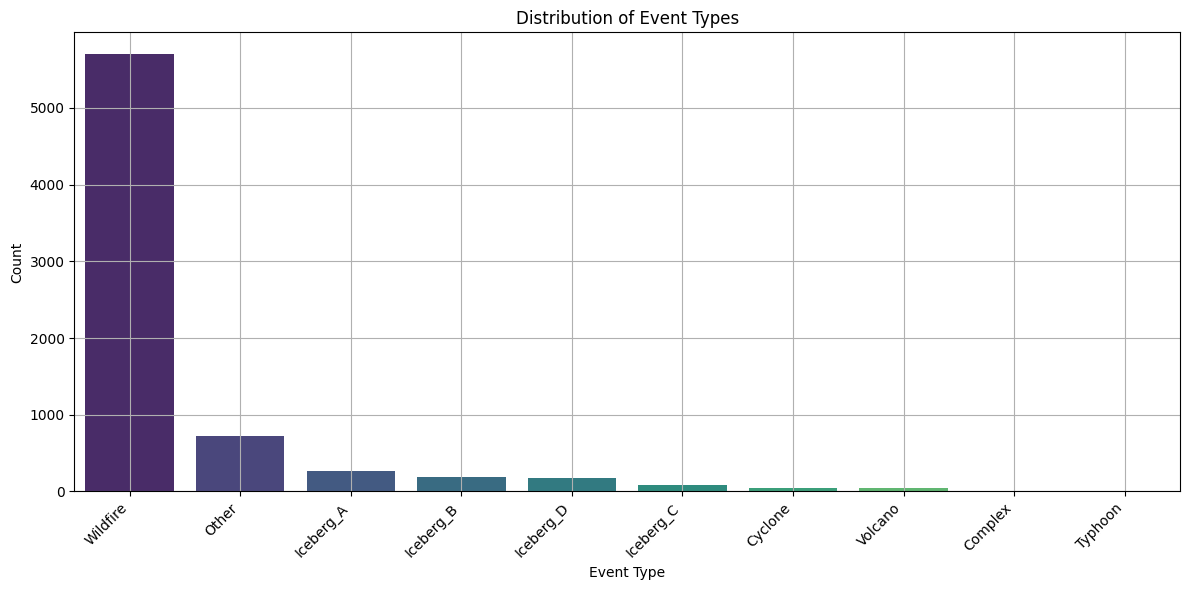

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=df['Event_type'].value_counts().index, y=df['Event_type'].value_counts().values, palette='viridis')
plt.title('Distribution of Event Types')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.grid()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

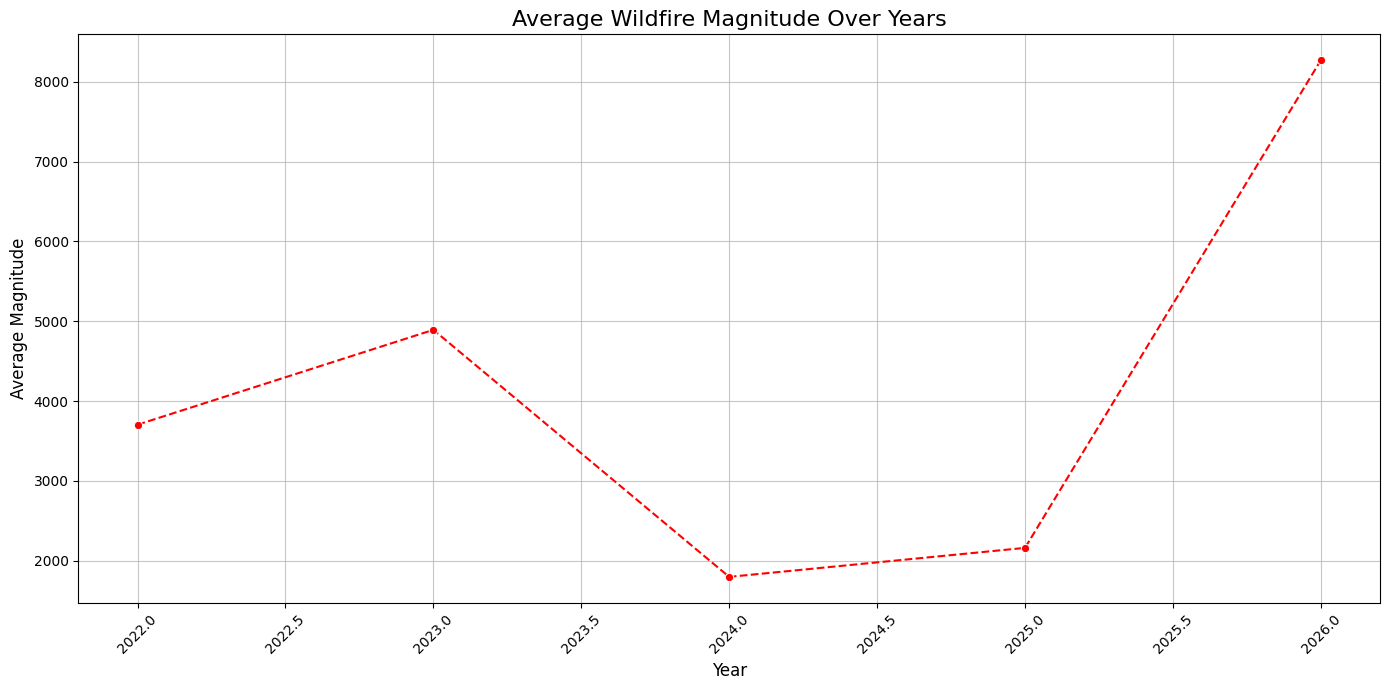

In [154]:
wildfire_data = df[df['Event_type'] == 'Wildfire']

# Group by year and calculate the average magnitude
wildfire_magnitude_by_year = wildfire_data.groupby('year')['magnitude'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='year', y='magnitude', data=wildfire_magnitude_by_year, marker='o', color='red', linestyle='--')
plt.title('Average Wildfire Magnitude Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Magnitude', fontsize=12)
plt.grid(True, linestyle='-', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4653/1141378117.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='count', data=volcano_count_by_year, palette='rocket')


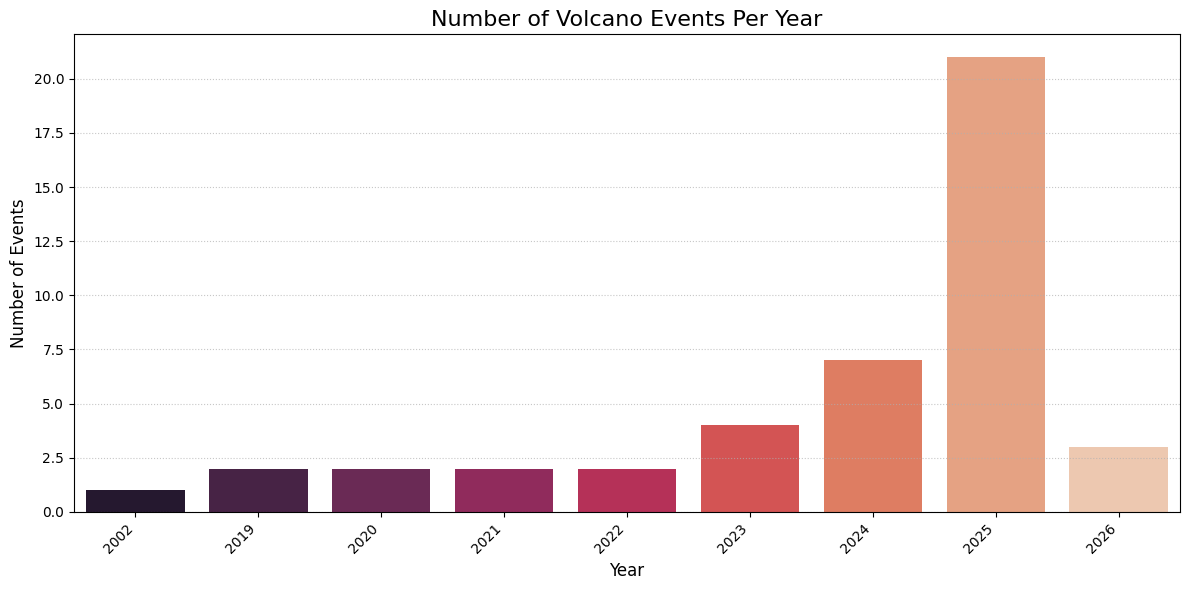

In [158]:
volcano_data = df[df['Event_type'] == 'Volcano']

# Count the number of volcano events per year
volcano_count_by_year = volcano_data.groupby('year').size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.barplot(x='year', y='count', data=volcano_count_by_year, palette='rocket')
plt.title('Number of Volcano Events Per Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [160]:
df

,Event_type,lat,lon,magnitude,year,month,day,hour,dayofweek
0,Typhoon,8.3000,151.5000,35.0,2026,4,9,18,3
1,Typhoon,8.2000,151.2000,40.0,2026,4,10,0,4
2,Typhoon,8.2000,151.0000,45.0,2026,4,10,6,4
3,Typhoon,8.1000,150.9000,55.0,2026,4,10,12,4
4,Typhoon,8.0000,151.0000,60.0,2026,4,10,18,4
...,...,...,...,...,...,...,...,...,...
7238,Iceberg_B,-66.3660,143.3638,844.0,2011,8,30,0,1
7239,Iceberg_B,-66.7354,142.6649,844.0,2013,4,8,0,0
7240,Iceberg_B,-66.3700,143.3900,844.0,2018,1,12,0,4
7241,Iceberg_C,-64.9955,96.1800,844.0,2011,8,30,0,1


In [161]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("final_hazard_dataset.csv")


print("\nBasic stats:")
print(df.describe())


Basic stats:
               lat          lon      magnitude         year        month  \
count  7243.000000  7243.000000    7243.000000  7243.000000  7243.000000   
mean      7.380854   -24.295215    1839.909462  2024.449952     6.401491   
std      36.574322    88.435780   11139.101721     0.988236     3.014154   
min     -77.690000  -179.860000       0.010000  2002.000000     1.000000   
25%     -15.758350   -94.776883     844.000000  2024.000000     4.000000   
50%       7.108131   -53.963710     844.000000  2024.000000     7.000000   
75%      36.121823    28.531475     844.000000  2025.000000     8.000000   
max      70.367698   179.790000  572804.000000  2026.000000    12.000000   

               day         hour    dayofweek  
count  7243.000000  7243.000000  7243.000000  
mean     15.940632    14.819274     2.909292  
std       8.599857     6.515383     1.873278  
min       1.000000     0.000000     0.000000  
25%       9.000000    10.000000     1.000000  
50%      16.000000 

In [163]:
# We cluster ONLY on latitude & longitude → this discovers natural "regions" of hazard activity
coords = np.radians(df[['lat', 'lon']].values)   # DBSCAN with haversine needs radians

# Earth's radius in km (for distance conversion)
kms_per_radian = 6371.0088

# ================== TUNING PARAMETERS ==================
# eps_km = maximum distance (in km) between two points to be in same cluster
#   → 200 km is a good starting point for regional hazards (typhoon tracks, iceberg zones, etc.)
#   → Smaller (50-100 km) = tighter clusters
#   → Larger (300-500 km) = broader regions
eps_km = 200
eps = eps_km / kms_per_radian

# min_samples = minimum number of events needed to form a core point of a cluster
min_samples = 5
# ======================================================

print(f"\nRunning DBSCAN with eps = {eps_km} km and min_samples = {min_samples}")

# ========================
# STEP 3: BUILD THE CLUSTERING MODEL (DBSCAN)
# ========================
dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric='haversine',      # correct distance on sphere
    algorithm='ball_tree'
)

df['cluster'] = dbscan.fit_predict(coords)


Running DBSCAN with eps = 200 km and min_samples = 5


In [165]:
n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
noise_count = (df['cluster'] == -1).sum()

print(f"\nClustering complete!")
print(f"   → Number of hazard regions (clusters): {n_clusters}")
print(f"   → Noise/outlier events: {noise_count} ({noise_count/len(df)*100:.1f}%)")


Clustering complete!
   → Number of hazard regions (clusters): 49
   → Noise/outlier events: 248 (3.4%)


In [166]:
# ========================
# STEP 4: ANALYZE & "PREDICT" REGIONS
# ========================
# Summary table → this is your "predicted regions"
cluster_summary = df.groupby('cluster').agg(
    num_events=('Event_type', 'count'),
    most_common_event=('Event_type', lambda x: x.mode()[0] if not x.empty else 'None'),
    avg_magnitude=('magnitude', 'mean'),
    avg_lat=('lat', 'mean'),
    avg_lon=('lon', 'mean')
).round(2).reset_index()

print("\n=== CLUSTER SUMMARY (Your Predicted Regions) ===")
print(cluster_summary)


=== CLUSTER SUMMARY (Your Predicted Regions) ===
    cluster  num_events most_common_event  avg_magnitude  avg_lat  avg_lon
0        -1         248          Wildfire         806.57     4.60    31.61
1         0          11           Typhoon          73.64     8.78   151.17
2         1        2516          Wildfire        3534.68    36.97   -99.75
3         2           8           Cyclone          73.75   -15.46   173.00
4         3          30           Cyclone         104.63    -8.86   155.09
5         4         105         Iceberg_C         145.29   -66.28    72.24
6         5         131          Wildfire        7292.27    65.03  -151.77
7         6         106         Iceberg_B         272.12   -72.54  -155.35
8         7         643          Wildfire         844.00   -17.44   135.57
9         8         283          Wildfire         844.00    55.95   121.50
10        9           7          Wildfire         844.00    19.55   102.07
11       10         310          Wildfire         

In [167]:
high_risk = cluster_summary[cluster_summary['num_events'] > cluster_summary['num_events'].quantile(0.75)]
print("\n HIGH-RISK REGIONS (most active):")
print(high_risk[['cluster', 'num_events', 'most_common_event', 'avg_magnitude']])


 HIGH-RISK REGIONS (most active):
    cluster  num_events most_common_event  avg_magnitude
0        -1         248          Wildfire         806.57
2         1        2516          Wildfire        3534.68
5         4         105         Iceberg_C         145.29
6         5         131          Wildfire        7292.27
7         6         106         Iceberg_B         272.12
8         7         643          Wildfire         844.00
9         8         283          Wildfire         844.00
11       10         310          Wildfire         844.00
20       19         431         Iceberg_A         378.46
28       27         804          Wildfire         844.00
31       30        1029          Wildfire         844.00
35       34          43          Wildfire         844.00
40       39         168          Wildfire         844.00


In [168]:
df.to_csv("final_hazard_dataset_with_clusters.csv", index=False)
print("\nClustered dataset saved as 'final_hazard_dataset_with_clusters.csv'")


Clustered dataset saved as 'final_hazard_dataset_with_clusters.csv'


/tmp/ipykernel_4653/4102046224.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_summary[cluster_summary['cluster'] != -1],
/tmp/ipykernel_4653/4102046224.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['cluster'] != -1], x='cluster', y='magnitude', palette='viridis')


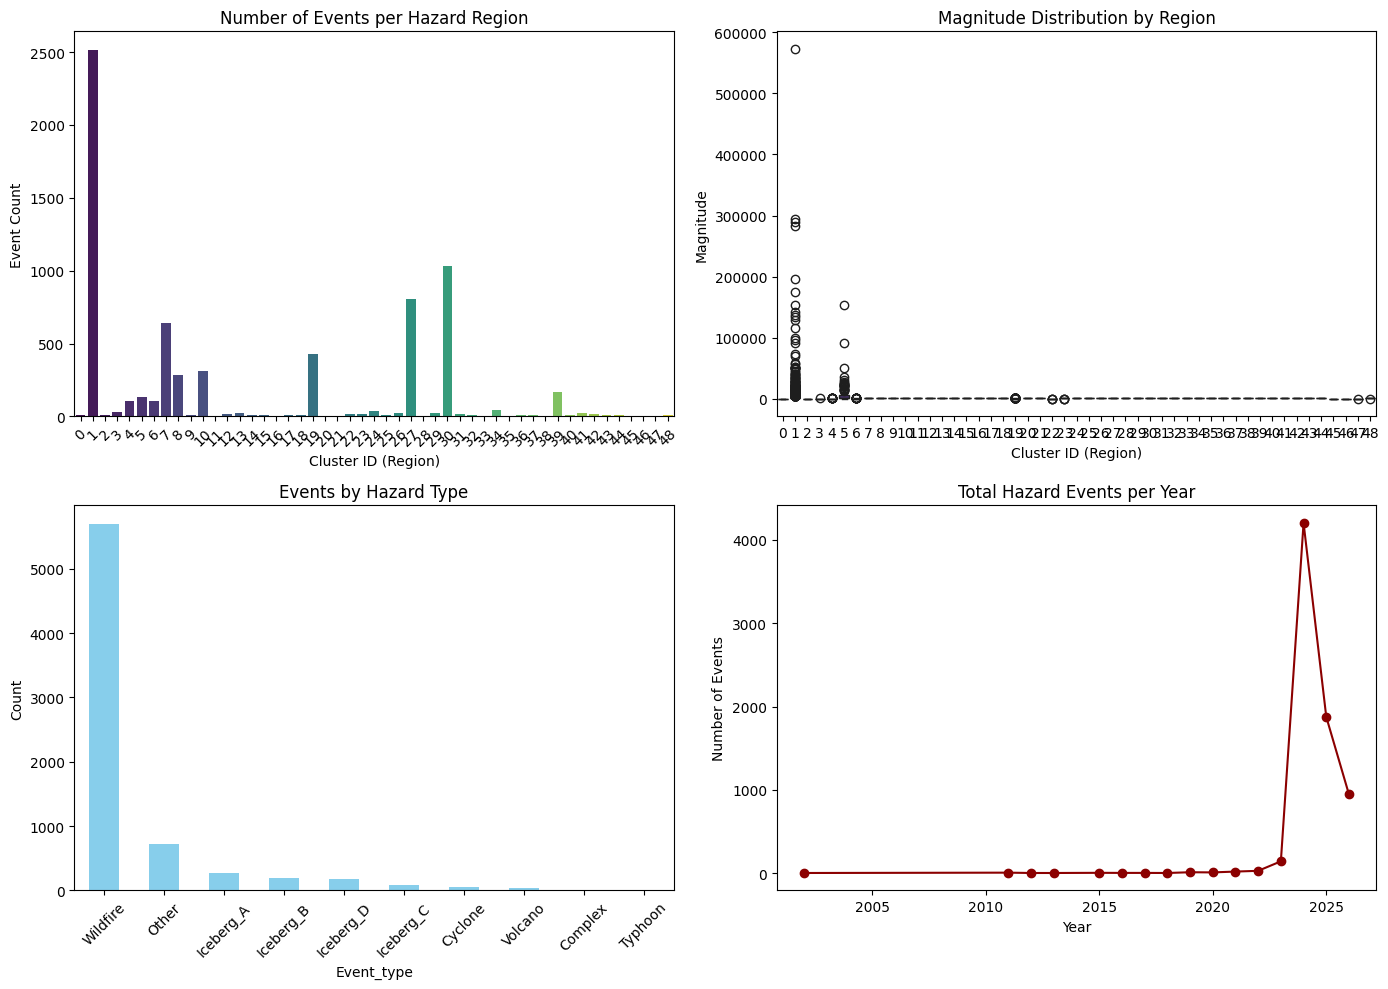

In [170]:
plt.figure(figsize=(14, 10))

# Graph 1: Events per region
plt.subplot(2, 2, 1)
sns.barplot(data=cluster_summary[cluster_summary['cluster'] != -1],
            x='cluster', y='num_events', palette='viridis')
plt.title('Number of Events per Hazard Region')
plt.xlabel('Cluster ID (Region)')
plt.ylabel('Event Count')
plt.xticks(rotation=45)

# Graph 2: Magnitude boxplot per region
plt.subplot(2, 2, 2)
sns.boxplot(data=df[df['cluster'] != -1], x='cluster', y='magnitude', palette='viridis')
plt.title('Magnitude Distribution by Region')
plt.xlabel('Cluster ID (Region)')
plt.ylabel('Magnitude')

# Graph 3: Events by Event Type (overall)
plt.subplot(2, 2, 3)
df['Event_type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Events by Hazard Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Graph 4: Events per year
plt.subplot(2, 2, 4)
df.groupby('year').size().plot(kind='line', marker='o', color='darkred')
plt.title('Total Hazard Events per Year')
plt.ylabel('Number of Events')
plt.xlabel('Year')

plt.tight_layout()
plt.show()

In [171]:
# Map 1: All events colored by discovered region/cluster
fig1 = px.scatter_geo(
    df,
    lat='lat',
    lon='lon',
    color='cluster',                    # ← color by predicted region
    hover_name='Event_type',
    hover_data=['magnitude', 'year', 'month', 'day'],
    title=f'Hazard Regions Discovered by DBSCAN (eps={eps_km} km)',
    labels={'cluster': 'Region ID'},
    color_continuous_scale=px.colors.sequential.Plasma,
    projection='natural earth',         # good global projection
    size='magnitude',                   # optional: size by magnitude
    size_max=15
)
fig1.update_traces(marker=dict(line=dict(width=0.5, color='DarkSlateGrey')))
fig1.show()

In [172]:
# Map 2: Clean view (no noise points)
df_clean = df[df['cluster'] != -1]
fig2 = px.scatter_geo(
    df_clean,
    lat='lat',
    lon='lon',
    color='cluster',
    hover_name='Event_type',
    hover_data=['magnitude', 'year'],
    title='Clustered Hazard Regions (Noise Removed)',
    projection='natural earth'
)
fig2.show()

In [173]:
fig3 = px.scatter_geo( # Map 3: Just for comparison — colored by Event Type
    df,
    lat='lat',
    lon='lon',
    color='Event_type',
    hover_name='Event_type',
    title='All Hazard Events Colored by Type (No Clustering)',
    projection='natural earth'
)
fig3.show()

In [177]:
# === ADD THESE IMPORTS (if not already there) ===
from sklearn.metrics.pairwise import haversine_distances
import numpy as np

# === PREDICT REGION FUNCTION (Fixed Version) ===
def predict_region(new_lat: float, new_lon: float, eps_km: float = 200):
    """
    Predicts which existing hazard region a new event belongs to.
    """
    # Convert new point to radians
    new_point = np.radians([[new_lat, new_lon]])

    # Get core points (more reliable than all points)
    core_coords = coords[dbscan.core_sample_indices_]
    core_labels = df.iloc[dbscan.core_sample_indices_]['cluster'].values

    # Calculate real distances in km
    distances = haversine_distances(new_point, core_coords) * 6371.0

    min_dist = distances.min()
    nearest_idx = distances.argmin()
    nearest_cluster = int(core_labels[nearest_idx])

    if min_dist <= eps_km:
        # Find the most common event type in that region
        most_common_event = df[df['cluster'] == nearest_cluster]['Event_type'].mode()[0]
        return f"→ Assigned to Region {nearest_cluster} ({most_common_event} hotspot)\n" \
               f"   Distance: {min_dist:.1f} km from region center"
    else:
        return f"→ NEW / Noise Event\n" \
               f"   Closest region: {nearest_cluster} ({min_dist:.1f} km away - outside 200km threshold)"

# ========================
# TEST IT
# ========================
print(predict_region(36.5, -120.5))   # California example
print("\nAnother test:")
print(predict_region(-70.0, -40.0))   # Antarctica / Iceberg area

→ Assigned to Region 1 (Wildfire hotspot)
   Distance: 37.8 km from region center

Another test:
→ Assigned to Region 19 (Iceberg_A hotspot)
   Distance: 63.5 km from region center


In [178]:
def predict_region(new_lat: float, new_lon: float, eps_km: float = 200):
    new_point = np.radians([[new_lat, new_lon]])
    core_coords = coords[dbscan.core_sample_indices_]
    core_labels = df.iloc[dbscan.core_sample_indices_]['cluster'].values

    distances = haversine_distances(new_point, core_coords) * 6371.0
    min_dist = float(distances.min())
    nearest_cluster = int(core_labels[distances.argmin()])

    if min_dist <= eps_km:
        most_common = df[df['cluster'] == nearest_cluster]['Event_type'].mode()[0]
        return {
            "status": "Assigned",
            "region": nearest_cluster,
            "distance_km": round(min_dist, 1),
            "most_common_event": most_common
        }
    else:
        return {
            "status": "New/Noise",
            "closest_region": nearest_cluster,
            "distance_km": round(min_dist, 1)
        }

# Test
result = predict_region(36.5, -120.5)
print(result)

{'status': 'Assigned', 'region': 1, 'distance_km': 37.8, 'most_common_event': 'Wildfire'}
